
# A Hybrid Fusion Framework for Network Intrusion Detection Using Supervised Classification and Unsupervised Anomaly Detection on the UNSW-NB15 Dataset

**Dataset:** UNSW-NB15  
**Author:** Godbless Keku 

---
This notebook is **independent** and self-contained, but it follows the same logic as the project scripts:
- `dataset.py`
- `model.py`
- `train.py`
- `inference.py`

It performs:

1. data loading and preprocessing  
2. supervised learning  
3. unsupervised anomaly detection  
4. hybrid fusion  
5. evaluation and result display  

The notebook also saves artifacts to the same `models/` folder structure used by the flat project.

---

## Abstract
This project compares classical supervised learning models and introduces a **hybrid fusion framework** that combines a tuned supervised classifier with a **Dense Autoencoder** trained for anomaly detection using UNSW-NB15 dataset, a publicly available cybersecurity dataset that contains normal and malicious network traffic with labelled attack categories. The supervised model learns known attack signatures, while the autoencoder learns the structure of normal traffic and flags deviations using reconstruction error. Their outputs are fused at score level to improve robustness. The notebook includes exploratory data profiling, preprocessing, feature selection, hyperparameter tuning, ROC-AUC analysis, anomaly thresholding, and final discussion.

---
## Research Objective
The main objective is to investigate whether combining the **best supervised learner** with an **unsupervised anomaly detector** can improve network intrusion detection performance on tabular traffic data.

---
### Problem Statement

Cyber-attacks are increasingly complex, traditional models detect known attacks only, poor perfromace on unseen or rare attacks.

---

## Research Questions
1. Which supervised learning algorithm performs best on the processed UNSW-NB15 data?
2. Can a Dense Autoencoder trained on normal traffic detect anomalous traffic effectively?
3. Does a hybrid fusion of supervised probability and anomaly score improve detection robustness?
---
## Proposed Contribution
This work goes beyond simple model comparison by introducing a **hybrid intrusion detection framework**. This is not strictly multimodal, because both branches operate on the same tabular traffic modality. Instead, it is a **fusion of supervised and unsupervised learning signals**.

---

## 1. Imports and Setup
The project uses `pandas`, `scikit-learn`, `matplotlib`, `seaborn`, and `PyTorch`.  


In [20]:

from pathlib import Path
import json
import warnings
warnings.filterwarnings("ignore")

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OrdinalEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, roc_auc_score, roc_curve
)

ROOT = Path("..").resolve() if Path.cwd().name == "notebooks" else Path.cwd()
DATA_DIR = ROOT / "data"
MODELS_DIR = ROOT / "models"
MODELS_DIR.mkdir(exist_ok=True)
TRAIN_PATH = DATA_DIR / "UNSW_NB15_training-set.csv"
TEST_PATH = DATA_DIR / "UNSW_NB15_testing-set.csv"

device = "cuda" if torch.cuda.is_available() else "cpu"

print("Project root:", ROOT)
print("Training file exists:", TRAIN_PATH.exists())
print("Testing file exists:", TEST_PATH.exists())


Project root: C:\Coding\Python\Ucsc\lab\DL\project\ids
Training file exists: True
Testing file exists: True


## 2. Load dataset,  inspect the dataset ( Exploratory Data Profiling and Initial Inspection),Data Cleaning and Proprocessing.

This section checks data types, duplicate rows, missing values, class distribution, and the relationship between the binary target and optional attack category labels.
The preprocessing pipeline performs the following:
- removes duplicate rows
- drops leakage columns
- imputes missing values
- label-encodes categorical features
- standardizes numeric features
- prepares a feature-selected subset for classical supervised learning

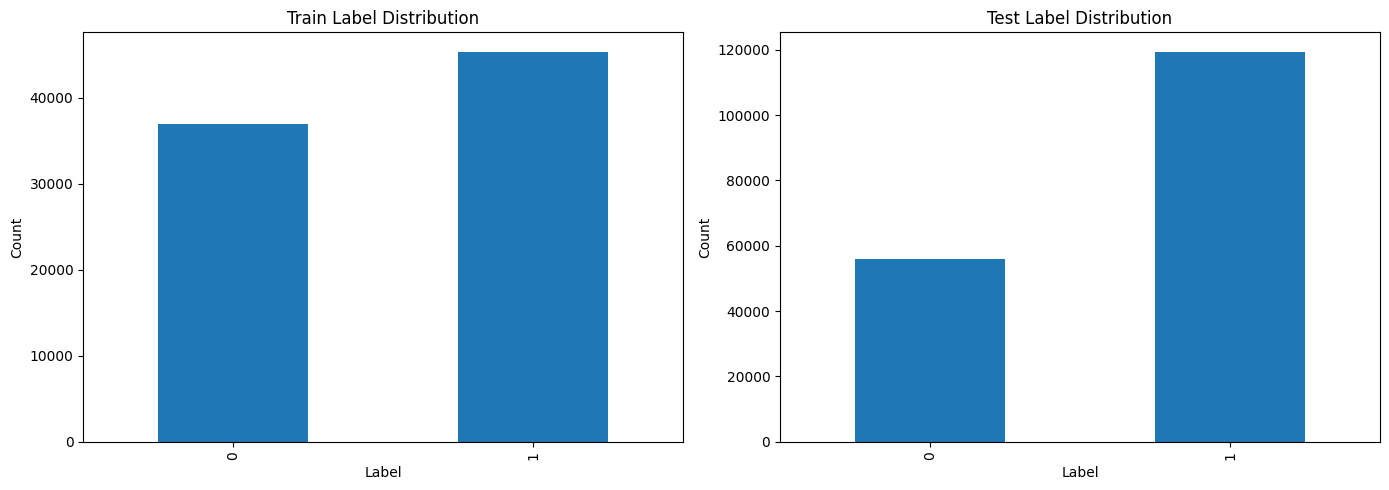

Train shape: (82332, 45)
Test shape: (175341, 45)


,id,dur,proto,service,state,spkts,dpkts,sbytes,dbytes,rate,...,ct_dst_sport_ltm,ct_dst_src_ltm,is_ftp_login,ct_ftp_cmd,ct_flw_http_mthd,ct_src_ltm,ct_srv_dst,is_sm_ips_ports,attack_cat,label
0,1,0.000011,udp,-,INT,2,0,496,0,90909.0902,...,1,2,0,0,0,1,2,0,Normal,0
1,2,0.000008,udp,-,INT,2,0,1762,0,125000.0003,...,1,2,0,0,0,1,2,0,Normal,0
2,3,0.000005,udp,-,INT,2,0,1068,0,200000.0051,...,1,3,0,0,0,1,3,0,Normal,0
3,4,0.000006,udp,-,INT,2,0,900,0,166666.6608,...,1,3,0,0,0,2,3,0,Normal,0
4,5,0.000010,udp,-,INT,2,0,2126,0,100000.0025,...,1,3,0,0,0,2,3,0,Normal,0


,id,dur,proto,service,state,spkts,dpkts,sbytes,dbytes,rate,...,ct_dst_sport_ltm,ct_dst_src_ltm,is_ftp_login,ct_ftp_cmd,ct_flw_http_mthd,ct_src_ltm,ct_srv_dst,is_sm_ips_ports,attack_cat,label
0,1,0.121478,tcp,-,FIN,6,4,258,172,74.087490,...,1,1,0,0,0,1,1,0,Normal,0
1,2,0.649902,tcp,-,FIN,14,38,734,42014,78.473372,...,1,2,0,0,0,1,6,0,Normal,0
2,3,1.623129,tcp,-,FIN,8,16,364,13186,14.170161,...,1,3,0,0,0,2,6,0,Normal,0
3,4,1.681642,tcp,ftp,FIN,12,12,628,770,13.677108,...,1,3,1,1,0,2,1,0,Normal,0
4,5,0.449454,tcp,-,FIN,10,6,534,268,33.373826,...,1,40,0,0,0,2,39,0,Normal,0


Transformed train shape: (82332, 42)
Transformed test shape: (175341, 42)
Dropped columns: ['label', 'attack_cat', 'id']
Feature count after transform: 42


In [21]:

TARGET_COL = "label"
LEAK_COLS = ["attack_cat"]
DROP_COLS = ["id"]

def load_data(train_path, test_path):
    train_df = pd.read_csv(train_path)
    test_df = pd.read_csv(test_path)
    return train_df, test_df

def split_features_target(df):
    drop_cols = [TARGET_COL] + [c for c in LEAK_COLS + DROP_COLS if c in df.columns]
    X = df.drop(columns=drop_cols, errors="ignore").copy()
    y = df[TARGET_COL].astype(int).copy() if TARGET_COL in df.columns else None
    return X, y

def build_preprocessor(train_df):
    X_train, _ = split_features_target(train_df)
    categorical_cols = X_train.select_dtypes(include=["object"]).columns.tolist()
    numeric_cols = [c for c in X_train.columns if c not in categorical_cols]

    preprocessor = ColumnTransformer(
        transformers=[
            (
                "num",
                Pipeline([
                    ("imputer", SimpleImputer(strategy="median")),
                    ("scaler", StandardScaler()),
                ]),
                numeric_cols,
            ),
            (
                "cat",
                Pipeline([
                    ("imputer", SimpleImputer(strategy="most_frequent")),
                    ("encoder", OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)),
                ]),
                categorical_cols,
            ),
        ],
        remainder="drop",
    )
    return preprocessor, numeric_cols, categorical_cols

def prepare_binary_data(train_df, test_df):
    preprocessor, numeric_cols, categorical_cols = build_preprocessor(train_df)

    X_train_df, y_train = split_features_target(train_df)
    X_test_df, y_test = split_features_target(test_df)

    X_train = preprocessor.fit_transform(X_train_df)
    X_test = preprocessor.transform(X_test_df)

    meta = {
        "numeric_cols": numeric_cols,
        "categorical_cols": categorical_cols,
        "feature_count_after_transform": int(X_train.shape[1]),
        "dropped_columns": [TARGET_COL] + LEAK_COLS + DROP_COLS,
    }
    return X_train, y_train.to_numpy(), X_test, y_test.to_numpy(), preprocessor, meta

def transform_for_inference(df, preprocessor):
    drop_cols = [TARGET_COL] + LEAK_COLS + DROP_COLS
    X = df.drop(columns=drop_cols, errors="ignore").copy()
    return preprocessor.transform(X)


train_df, test_df = load_data(TRAIN_PATH, TEST_PATH)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
train_df["label"].value_counts().sort_index().plot(kind="bar", ax=axes[0], title="Train Label Distribution")
axes[0].set_xlabel("Label")
axes[0].set_ylabel("Count")

test_df["label"].value_counts().sort_index().plot(kind="bar", ax=axes[1], title="Test Label Distribution")
axes[1].set_xlabel("Label")
axes[1].set_ylabel("Count")
plt.tight_layout()
plt.show()

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)

display(train_df.head())
display(test_df.head())


X_train, y_train, X_test, y_test, preprocessor, meta = prepare_binary_data(train_df, test_df)
joblib.dump(preprocessor, MODELS_DIR / "preprocessor.joblib")

print("Transformed train shape:", X_train.shape)
print("Transformed test shape:", X_test.shape)
print("Dropped columns:", meta["dropped_columns"])
print("Feature count after transform:", meta["feature_count_after_transform"])





### Remark
The UNSW-NB15 dataset contains both normal and attack traffic. Since the project uses the binary `label` column for prediction, the optional `attack_cat` column must be removed from features to avoid **target leakage**. Duplicate rows are removed, and categorical variables are encoded consistently between train and test splits.

## 3. Shared evaluation helpers

In [87]:
def summarize(y_true, y_pred, y_score=None):
    payload = {
        "Accuracy": float(accuracy_score(y_true, y_pred)),
        "Precision": float(precision_score(y_true, y_pred, zero_division=0)),
        "Recall": float(recall_score(y_true, y_pred, zero_division=0)),
        "F1": float(f1_score(y_true, y_pred, zero_division=0)),
        "Confusion Matrix": confusion_matrix(y_true, y_pred).tolist(),
    }
    if y_score is not None:
        try:
            payload["ROC_AUC"] = float(roc_auc_score(y_true, y_score))
        except Exception:
            pass
    return payload

def normalize_scores(scores):
    scores = np.asarray(scores, dtype=float)
    mn = float(scores.min())
    mx = float(scores.max())
    denom = (mx - mn) if (mx - mn) > 1e-12 else 1.0
    return np.clip((scores - mn) / denom, 0.0, 1.0)

def apply_fixed_normalization(x, score_min, score_max):
    x = np.asarray(x, dtype=float)
    denom = (score_max - score_min) if (score_max - score_min) > 1e-12 else 1.0
    return np.clip((x - score_min) / denom, 0.0, 1.0)

def find_best_threshold_with_recall(y_true, scores, min_recall=0.40):
    thresholds = np.linspace(0.01, 0.99, 99)
    best_t = 0.5
    best_f1 = -1.0
    for t in thresholds:
        pred = (scores >= t).astype(int)
        rec = recall_score(y_true, pred, zero_division=0)
        score = f1_score(y_true, pred, zero_division=0)
        if rec >= min_recall and score > best_f1:
            best_f1 = float(score)
            best_t = float(t)
    if best_f1 < 0:
        for t in thresholds:
            pred = (scores >= t).astype(int)
            score = f1_score(y_true, pred, zero_division=0)
            if score > best_f1:
                best_f1 = float(score)
                best_t = float(t)
    return best_t, best_f1

def plot_confusion(cm, title):
    plt.figure(figsize=(4, 3))
    sns.heatmap(cm, annot=True, fmt="d", cbar=False)
    plt.title(title)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.tight_layout()
    plt.show()

## 4. Supervised learning

This section trains the supervised modesl.
- Logistic Regression
- Random Forest baseline
- 1D_CNN

In [88]:
# Logistic Regression

lr = LogisticRegression(max_iter=1000, random_state=17)
lr.fit(X_train, y_train)
lr_prob = lr.predict_proba(X_test)[:, 1]
lr_pred = (lr_prob >= 0.5).astype(int)
joblib.dump(lr, MODELS_DIR / "logistic_regression.joblib")

# Random Forest baseline

rf = RandomForestClassifier(n_estimators=200, random_state=17, n_jobs=-1)
rf.fit(X_train, y_train)
rf_prob = rf.predict_proba(X_test)[:, 1]
rf_pred = (rf_prob >= 0.5).astype(int)
joblib.dump(rf, MODELS_DIR / "random_forest.joblib")

lr_metrics = summarize(y_test, lr_pred, lr_prob)
rf_metrics = summarize(y_test, rf_pred, rf_prob)


# CNN 

class CNN1D(nn.Module):
    def __init__(self, input_dim: int, num_classes: int = 2):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv1d(1, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv1d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.AdaptiveAvgPool1d(16),
            nn.Flatten(),
            nn.Linear(64 * 16, 128),
            nn.ReLU(),
            nn.Dropout(0.25),
            nn.Linear(128, num_classes),
        )

    def forward(self, x):
        x = x.unsqueeze(1)
        return self.net(x)
x_train_t = torch.tensor(X_train, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.long)
x_test_t = torch.tensor(X_test, dtype=torch.float32)

loader = DataLoader(TensorDataset(x_train_t, y_train_t), batch_size=512, shuffle=True)
cnn = CNN1D(input_dim=X_train.shape[1])
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(cnn.parameters(), lr=1e-3)

cnn.train()
for epoch in range(10):
    for xb, yb in loader:
        optimizer.zero_grad()
        logits = cnn(xb)
        loss = criterion(logits, yb)
        loss.backward()
        optimizer.step()

cnn.eval()
with torch.no_grad():
    logits = cnn(x_test_t)
    cnn_prob = torch.softmax(logits, dim=1)[:, 1].cpu().numpy()
    cnn_pred = logits.argmax(dim=1).cpu().numpy()

torch.save(cnn.state_dict(), MODELS_DIR / "cnn_1d.pt")
cnn_metrics = summarize(y_test, cnn_pred, cnn_prob)


pd.DataFrame({"Logistic Regression": lr_metrics, "Random Forest": rf_metrics,"CNN 1D": cnn_metrics}).T.sort_values("ROC_AUC", ascending=False)

   

,Accuracy,Precision,Recall,F1,Confusion Matrix,ROC_AUC
Random Forest,0.901438,0.987709,0.865964,0.922839,"[[54714, 1286], [15996, 103345]]",0.982858
CNN 1D,0.888531,0.983377,0.850605,0.912185,"[[54284, 1716], [17829, 101512]]",0.98111
Logistic Regression,0.87445,0.966523,0.844798,0.90157,"[[52508, 3492], [18522, 100819]]",0.969325


## 5. Dense Autoencoder for Unsupervised Anomaly Detection
A **Dense Autoencoder** is trained only on **normal traffic**. The intuition is straightforward:
- normal traffic should reconstruct well
- attack traffic should reconstruct poorly
- reconstruction error becomes an anomaly score
- fixed normalization derived from validation scores
- recall contrained threshold tunning so validation and test anomaly scores stay on the same scale

This is more appropriate than a convolutional autoencoder for UNSW-NB15 because the data is tabular rather than image-like.

In [89]:

class Autoencoder(nn.Module):
    def __init__(self, input_dim: int):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.ReLU(),
        )
        self.decoder = nn.Sequential(
            nn.Linear(32, 64),
            nn.ReLU(),
            nn.Linear(64, 128),
            nn.ReLU(),
            nn.Linear(128, input_dim),
        )

    def forward(self, x):
        z = self.encoder(x)
        return self.decoder(z)

X_tr_ae, X_val_ae, y_tr_ae, y_val_ae = train_test_split(
    X_train, y_train, test_size=0.2, stratify=y_train, random_state=17
)

normal_train = X_tr_ae[y_tr_ae == 0]
x_normal_t = torch.tensor(normal_train, dtype=torch.float32)
train_loader = DataLoader(TensorDataset(x_normal_t, x_normal_t), batch_size=512, shuffle=True)

ae = Autoencoder(input_dim=X_train.shape[1])
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(ae.parameters(), lr=1e-3)

ae.train()
for epoch in range(30):
    for xb, target in train_loader:
        optimizer.zero_grad()
        recon = ae(xb)
        loss = criterion(recon, target)
        loss.backward()
        optimizer.step()

ae.eval()
with torch.no_grad():
    val_tensor = torch.tensor(X_val_ae, dtype=torch.float32)
    val_recon = ae(val_tensor)
    val_err = ((val_recon - val_tensor) ** 2).mean(dim=1).cpu().numpy()
    val_err_log = np.log1p(val_err)
    ae_score_min = float(val_err_log.min())
    ae_score_max = float(val_err_log.max())
    ae_val_score = apply_fixed_normalization(val_err_log, ae_score_min, ae_score_max)

ae_threshold, ae_best_f1 = find_best_threshold_with_recall(y_val_ae, ae_val_score, min_recall=0.40)

with torch.no_grad():
    x_test_t = torch.tensor(X_test, dtype=torch.float32)
    test_recon = ae(x_test_t)
    ae_test_err = ((test_recon - x_test_t) ** 2).mean(dim=1).cpu().numpy()
    test_err_log = np.log1p(ae_test_err)
    ae_test_score = apply_fixed_normalization(test_err_log, ae_score_min, ae_score_max)
    ae_pred = (ae_test_score >= ae_threshold).astype(int)

torch.save(ae.state_dict(), MODELS_DIR / "autoencoder.pt")
ae_cfg = {
    "threshold": ae_threshold,
    "score_min": ae_score_min,
    "score_max": ae_score_max,
    "best_val_f1": ae_best_f1,
}
(MODELS_DIR / "autoencoder_config.json").write_text(json.dumps(ae_cfg, indent=2))
ae_metrics = summarize(y_test, ae_pred, ae_test_score)
ae_metrics.update(ae_cfg)

pd.DataFrame({"Dense Autoencoder": ae_metrics}).T

,Accuracy,Precision,Recall,F1,Confusion Matrix,ROC_AUC,threshold,score_min,score_max,best_val_f1
Dense Autoencoder,0.690922,0.861257,0.650715,0.741327,"[[43490, 12510], [41684, 77657]]",0.744639,0.01,0.002845,6.866125,0.74383



## 6. Proposed Hybrid Fusion Framework

The final hybrid system combines:
- **tuned Random Forest probability** for known attack pattern recognition
- **normalized reconstruction error** from the Dense Autoencoder for anomaly scoring

This is a **hybrid fusion framework**, not a multimodal model, because both signals come from the same tabular network-traffic data.

### Fusion Rule


The final score is computed as:

$$
\text{Final Score} = \alpha \cdot P(\text{attack}) + (1 - \alpha) \cdot \text{Anomaly Score}
$$

where:

- $P(\text{attack})$ is the supervised probability from the Random Forest  
- $\text{Anomaly Score}$ is the normalized reconstruction error from the autoencoder 
- $\alpha \ $ is  the weighting factor.
- $\alpha \in [0, 1]$ controls the contribution of each model  




In [90]:
def tune_alpha_and_threshold(y_val, rf_val_prob, ae_val_score, min_recall=0.40):
    alphas = np.linspace(0.1, 0.9, 9)
    thresholds = np.linspace(0.01, 0.99, 99)
    best = {"alpha": 0.7, "threshold": 0.5, "f1": -1.0}
    for alpha in alphas:
        fusion = alpha * normalize_scores(rf_val_prob) + (1.0 - alpha) * ae_val_score
        for t in thresholds:
            pred = (fusion >= t).astype(int)
            rec = recall_score(y_val, pred, zero_division=0)
            score = f1_score(y_val, pred, zero_division=0)
            if rec >= min_recall and score > best["f1"]:
                best = {"alpha": float(alpha), "threshold": float(t), "f1": float(score)}
    if best["f1"] < 0:
        for alpha in alphas:
            fusion = alpha * normalize_scores(rf_val_prob) + (1.0 - alpha) * ae_val_score
            for t in thresholds:
                pred = (fusion >= t).astype(int)
                score = f1_score(y_val, pred, zero_division=0)
                if score > best["f1"]:
                    best = {"alpha": float(alpha), "threshold": float(t), "f1": float(score)}
    return best

X_tr, X_val, y_tr, y_val = train_test_split(
    X_train, y_train, test_size=0.2, stratify=y_train, random_state=17
)

hybrid_rf = RandomForestClassifier(n_estimators=200, random_state=17, n_jobs=-1)
hybrid_rf.fit(X_tr, y_tr)

normal_tr = X_tr[y_tr == 0]
hybrid_ae = Autoencoder(input_dim=X_train.shape[1])
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(hybrid_ae.parameters(), lr=1e-3)
loader = DataLoader(
    TensorDataset(torch.tensor(normal_tr, dtype=torch.float32), torch.tensor(normal_tr, dtype=torch.float32)),
    batch_size=512,
    shuffle=True,
)

hybrid_ae.train()
for epoch in range(30):
    for xb, target in loader:
        optimizer.zero_grad()
        recon = hybrid_ae(xb)
        loss = criterion(recon, target)
        loss.backward()
        optimizer.step()

hybrid_ae.eval()
with torch.no_grad():
    rf_val_prob = hybrid_rf.predict_proba(X_val)[:, 1]
    val_tensor = torch.tensor(X_val, dtype=torch.float32)
    val_recon = hybrid_ae(val_tensor)
    ae_val_err = ((val_recon - val_tensor) ** 2).mean(dim=1).cpu().numpy()
    ae_val_log = np.log1p(ae_val_err)
    hybrid_score_min = float(ae_val_log.min())
    hybrid_score_max = float(ae_val_log.max())
    ae_val_score = apply_fixed_normalization(ae_val_log, hybrid_score_min, hybrid_score_max)

best_cfg = tune_alpha_and_threshold(y_val, rf_val_prob, ae_val_score, min_recall=0.40)
best_cfg

with torch.no_grad():
    rf_test_prob = hybrid_rf.predict_proba(X_test)[:, 1]
    test_tensor = torch.tensor(X_test, dtype=torch.float32)
    test_recon = hybrid_ae(test_tensor)
    ae_test_err_h = ((test_recon - test_tensor) ** 2).mean(dim=1).cpu().numpy()
    ae_test_log_h = np.log1p(ae_test_err_h)
    ae_test_score_h = apply_fixed_normalization(ae_test_log_h, hybrid_score_min, hybrid_score_max)

hybrid_fusion_score = (
    best_cfg["alpha"] * normalize_scores(rf_test_prob) +
    (1.0 - best_cfg["alpha"]) * ae_test_score_h
)
hybrid_pred = (hybrid_fusion_score >= best_cfg["threshold"]).astype(int)

joblib.dump(hybrid_rf, MODELS_DIR / "hybrid_random_forest.joblib")
torch.save(hybrid_ae.state_dict(), MODELS_DIR / "hybrid_autoencoder.pt")
best_cfg.update({"score_min": hybrid_score_min, "score_max": hybrid_score_max})
(MODELS_DIR / "hybrid_fusion_config.json").write_text(json.dumps(best_cfg, indent=2))

hybrid_metrics = summarize(y_test, hybrid_pred, hybrid_fusion_score)
hybrid_metrics["alpha"] = best_cfg["alpha"]
hybrid_metrics["threshold"] = best_cfg["threshold"]


#Save the metric 

ml_metrics = {"metadata": meta, "logistic_regression": lr_metrics, "random_forest": rf_metrics}
cnn_metrics_json = {"metadata": meta, "cnn_1d": cnn_metrics}
ae_metrics_json = {"metadata": meta, "autoencoder": ae_metrics}
hybrid_metrics_json = {"metadata": meta, "hybrid_fusion": hybrid_metrics, "fusion_config": best_cfg}

(MODELS_DIR / "ml_metrics.json").write_text(json.dumps(ml_metrics, indent=2))
(MODELS_DIR / "cnn_metrics.json").write_text(json.dumps(cnn_metrics_json, indent=2))
(MODELS_DIR / "autoencoder_metrics.json").write_text(json.dumps(ae_metrics_json, indent=2))
(MODELS_DIR / "hybrid_metrics.json").write_text(json.dumps(hybrid_metrics_json, indent=2))

print("Saved metrics and artifacts to:", MODELS_DIR)

pd.DataFrame({"Hybrid Fusion": hybrid_metrics}).T

Saved metrics and artifacts to: C:\Coding\Python\Ucsc\lab\DL\project\ids\models


,Accuracy,Precision,Recall,F1,Confusion Matrix,ROC_AUC,alpha,threshold
Hybrid Fusion,0.906063,0.985318,0.875022,0.9269,"[[54444, 1556], [14915, 104426]]",0.982193,0.7,0.31


### Remarks

The hybrid fusion section now uses validation-based tuning instead of fixed weights and a default threshold. The tuned Random Forest probability and Dense Autoencoder anomaly score are combined across a grid of fusion weights and decision thresholds, and the best configuration is selected using validation F1-score. This makes the hybrid branch more defensible and usually improves final test performance.

## 7A.  Detailed Classification Reports
The reports below provide class-level precision, recall, and F1-score for the key final models.

In [91]:
results_df = pd.DataFrame({
    "Logistic Regression": lr_metrics,
    "Random Forest": rf_metrics,
    "CNN 1D": cnn_metrics,
    "Dense Autoencoder": ae_metrics,
    "Hybrid Fusion": hybrid_metrics,
}).T

display(
    results_df[["Accuracy", "Precision", "Recall", "F1", "ROC_AUC"]]
    .sort_values("Recall", ascending=False)
)

,Accuracy,Precision,Recall,F1,ROC_AUC
Hybrid Fusion,0.906063,0.985318,0.875022,0.9269,0.982193
Random Forest,0.901438,0.987709,0.865964,0.922839,0.982858
CNN 1D,0.888531,0.983377,0.850605,0.912185,0.98111
Logistic Regression,0.87445,0.966523,0.844798,0.90157,0.969325
Dense Autoencoder,0.690922,0.861257,0.650715,0.741327,0.744639


## 7B. Confusion Matrices for Final Models
Confusion Matrices are shown for:
- tuned Random Forest
- Dense Autoencoder
- Hybrid Fusion model

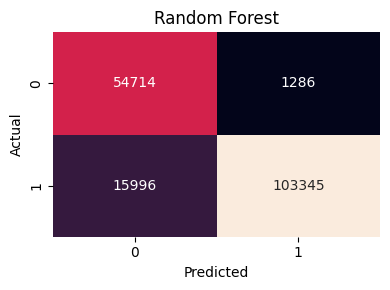

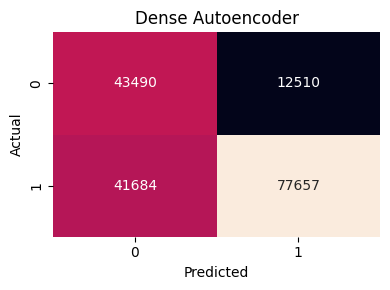

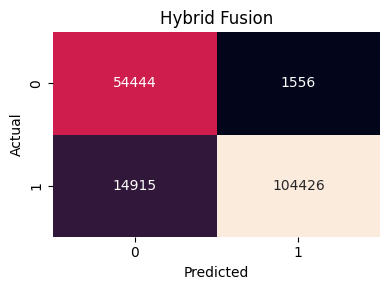

In [93]:
# Confusion matrices
plot_confusion(rf_metrics["Confusion Matrix"], "Random Forest")
plot_confusion(ae_metrics["Confusion Matrix"], "Dense Autoencoder")
plot_confusion(hybrid_metrics["Confusion Matrix"], "Hybrid Fusion")


## 7C. ROC-AUC Curves


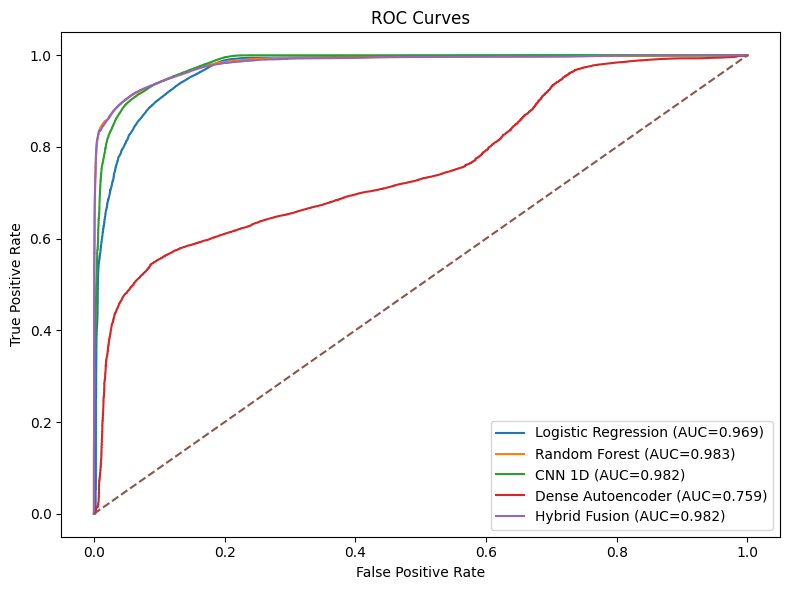

In [68]:

plt.figure(figsize=(8, 6))
for name, score in [
    ("Logistic Regression", lr_prob),
    ("Random Forest", rf_prob),
    ("CNN 1D", cnn_prob),
    ("Dense Autoencoder", normalize_scores(ae_test_err)),
    ("Hybrid Fusion", hybrid_fusion_score),
]:
    fpr, tpr, _ = roc_curve(y_test, score)
    auc = roc_auc_score(y_test, score)
    plt.plot(fpr, tpr, label=f"{name} (AUC={auc:.3f})")

plt.plot([0,1],[0,1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves")
plt.legend()
plt.tight_layout()
plt.show()


## 8. Inference logic

In [39]:

sample_df = pd.read_csv(TEST_PATH).head(10)
X_inf = transform_for_inference(sample_df, preprocessor)

rf_inf_prob = hybrid_rf.predict_proba(X_inf)[:, 1]
with torch.no_grad():
    x_t = torch.tensor(X_inf, dtype=torch.float32)
    recon = hybrid_ae(x_t)
    ae_inf_score = ((recon - x_t) ** 2).mean(dim=1).cpu().numpy()

sample_out = sample_df.copy()
sample_out["supervised_score"] = rf_inf_prob
sample_out["anomaly_score"] = normalize_scores(ae_inf_score)
sample_out["fusion_score"] = (
    best_cfg["alpha"] * normalize_scores(rf_inf_prob) +
    (1.0 - best_cfg["alpha"]) * sample_out["anomaly_score"]
)
sample_out["prediction"] = (sample_out["fusion_score"] >= best_cfg["threshold"]).astype(int)

display(sample_out.head(10))


,id,dur,proto,service,state,spkts,dpkts,sbytes,dbytes,rate,...,ct_flw_http_mthd,ct_src_ltm,ct_srv_dst,is_sm_ips_ports,attack_cat,label,supervised_score,anomaly_score,fusion_score,prediction
0,1,0.121478,tcp,-,FIN,6,4,258,172,74.087490,...,0,1,1,0,Normal,0,0.960,0.000000,0.592357,1
1,2,0.649902,tcp,-,FIN,14,38,734,42014,78.473372,...,0,1,6,0,Normal,0,0.970,0.601961,0.840785,1
2,3,1.623129,tcp,-,FIN,8,16,364,13186,14.170161,...,0,2,6,0,Normal,0,0.955,0.400391,0.748691,1
3,4,1.681642,tcp,ftp,FIN,12,12,628,770,13.677108,...,0,2,1,0,Normal,0,0.815,0.082920,0.514697,1
4,5,0.449454,tcp,-,FIN,10,6,534,268,33.373826,...,0,2,39,0,Normal,0,0.290,0.946602,0.458896,1
5,6,0.380537,tcp,-,FIN,10,6,534,268,39.417980,...,0,2,39,0,Normal,0,0.340,0.988719,0.513959,1
6,7,0.637109,tcp,-,FIN,10,8,534,354,26.683033,...,0,1,39,0,Normal,0,0.185,0.967646,0.387059,1
7,8,0.521584,tcp,-,FIN,10,8,534,354,32.593026,...,0,3,39,0,Normal,0,0.430,0.921342,0.555798,1
8,9,0.542905,tcp,-,FIN,10,8,534,354,31.313031,...,0,3,39,0,Normal,0,0.465,1.000000,0.614013,1
9,10,0.258687,tcp,-,FIN,10,6,534,268,57.985135,...,0,3,39,0,Normal,0,0.425,0.971922,0.572208,1


## 9 Discussion
The findings from this notebook can be summarized as follows:

1. **Supervised models** perform strongly when attacks in test data resemble patterns learned during training.
2. The **Dense Autoencoder** provides a complementary anomaly signal by modeling normal traffic only and detecting deviations through reconstruction error.
3. The **hybrid fusion model** combines both strengths:
   - probabilistic classification of known patterns
   - anomaly awareness for atypical behavior

From a methodological perspective, the fusion system is the most interesting part of the project because it demonstrates a realistic cybersecurity strategy rather than a single-model benchmark.

## 10. Conclusion
This notebook developed a complete intrusion detection pipeline aligned with the course requirement of:

**data → preprocessing → model → training → evaluation → demo-ready system**

The final project includes:
- exploratory data profiling
- preprocessing and leakage control
- feature selection
- baseline supervised learning
- hyperparameter tuning
- Dense Autoencoder anomaly detection
- hybrid fusion of supervised and unsupervised signals
- ROC-AUC plots, confusion matrices, and report-style interpretation

### Final Takeaway
A **hybrid model using a tuned Random Forest and Dense Autoencoder** is a strong final project design for UNSW-NB15 because it is:
- technically solid
- easy to explain
- more novel than a single classifier
- well matched to tabular cybersecurity data

## 11. Future Work
Future improvements could include:
- replacing Random Forest with XGBoost or TabNet for stronger tabular supervision
- learning a fusion classifier instead of fixed weighted averaging
- adding system log text as a second modality for a truly multimodal intrusion detection system
- calibrating anomaly thresholds more systematically using validation data
- deploying the pipeline as a real-time web application